# Multimodal Music Analysis

**Ομάδα:**
- Αθανάσιος Νικολέτας [sdi2300140]
- Αχιλλέας Πετρουλάκης [sdi2300171]


## 1.Installing dependances

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install nltk
%pip install gensim
%pip install wordcloud
%pip install vaderSentiment



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note

## 2. Loading the files and extracting data

In [2]:
import pandas as pd
import os

os.makedirs('../data/processed', exist_ok=True)

id_genres = pd.read_csv('../data/raw/id_genres.csv',sep='\t')
id_information = pd.read_csv('../data/raw/id_information.csv',sep='\t')
id_tags = pd.read_csv('../data/raw/id_tags.csv',sep='\t')


In [4]:
id_mfcc_stats = pd.read_csv('../data/raw/id_mfcc_stats.tsv.bz2',sep='\t',compression='bz2')

## Extract processed_lyrics from a tar.gz and creating processed_lyrics dictionary
for each file:

- get song_id from the filename
- read lyrics
- store to dictionary

make a dataframe using the dictionary

In [5]:
import tarfile
from pathlib import Path

processed_lyrics_dict = {}
with tarfile.open('../data/raw/processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile():
            file = tar.extractfile(member)
            song_id = Path(member.name).stem
            processed_lyrics_dict[song_id] = file.read().decode('utf-8')

processed_lyrics = pd.DataFrame(
    list(processed_lyrics_dict.items()),
    columns=['id', 'lyrics']
)

processed_lyrics




,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
2,h48f46ZsT9h0Z5Dm,arm side heart sleev chandeli fall stand under...
3,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...
4,ZmXVK43zlqdeq6z8,end see face recogn thing must left behind pro...
...,...,...
109264,YgII1tHAaAnh14Kf,
109265,5fU9VEvtc2T1J11g,whole town line outsid tent kid think see real...
109266,76qenAf8gYlH4pfq,see store one day think may make play futur mu...
109267,9F8jQjeibAuZinEP,close right sand stretch like child night trus...


## Filtering 
each song belongs in multiple genres, therefore we explode the genre column so that each song_id, genre becomes a separate row.Note that id_genres are not clean data and each song can belong to the same genre twice.So we have to remove duplicates.We then compute the top-5 most frequent genres and select songs that belong to at least one of them.Finally, we keep only the songs that exist in all three datasets (genres, lyrics, and stats) by merging them with the id.

In [20]:
def explode_df(df, to_explode, new_name):
    exploded = df.assign(**{new_name: df[to_explode].str.split(',')}).explode(new_name)
    exploded[new_name] = exploded[new_name].str.strip()
    return exploded.drop(columns=[to_explode])

def clean_df(df, to_clean):
    df = df.copy()
    df[to_clean] = df[to_clean].apply(
        lambda x: ','.join(dict.fromkeys(
            t.strip() for t in x.replace("-", " ").split(',')
        ))
    )
    return df

def find_top_n(df, to_find, n):
    exploded = explode_df(df, to_find, "temp")
    result = exploded["temp"].value_counts().head(n).reset_index()
    result.columns = [to_find, 'count']
    topn_list = result[to_find].tolist()
    list_counts = result['count'].tolist()
    return result, topn_list, list_counts


def find_in_list(df, to_find, values):
    mask = df[to_find].apply(
        lambda x: any(g.strip() in values for g in x.split(','))
    )
    return df[mask]

# #exploding dataframe
# id_genres_exploded = explode_df(df=id_genres,
#                                 to_explode="genres",
#                                 new_name="genre")


def print_info(top5_data_frame,final):
    print("~Top 5 genres with song count~")
    print(top5_data_frame)
    print("\nshape:", final.shape)
    print("\nfinal_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats")
    print(final.head())
    print("\ninfo")
    final.info()

    

In [21]:
#cleaning dataframe
id_tags      = clean_df(df=id_tags,to_clean="tags")


top5_data_frame,top5_list,top5_counts = find_top_n(df=id_genres,
                                                   to_find="genres",
                                                   n=5)

chosen_id_genres = find_in_list(df=id_genres, 
                                to_find='genres', 
                                values=top5_list).drop_duplicates(subset='id')

final = chosen_id_genres.merge(processed_lyrics, on='id', how='inner').merge(id_mfcc_stats, on='id', how='inner')
final = final.sample(n=7500, random_state=42).reset_index(drop=True)
final.to_csv('../data/processed/final_dataset.csv', index=False)

print_info(top5_data_frame=top5_data_frame,final=final)


~Top 5 genres with song count~
             genres  count
0              rock  23949
1               pop  20267
2        electronic  11739
3  alternative rock   7591
4        indie rock   7353

shape: (7500, 107)

final_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats
                 id                                   genres  \
0  rCBwys9UDbrFaqnx  rock,singer songwriter,classic rock,pop   
1  jwJo2kvKA2Gu3ftS       classic rock,rock,progressive rock   
2  bMnqQtrkYjnsrxnp              post hardcore,pop,metalcore   
3  ToVL2QCrrhcqq6Uc                               indie rock   
4  0U91aHvEcuFKaBD1                      folk,indie rock,emo   

                                              lyrics    MFCC000    MFCC001  \
0  well tell everyon disgrac drag name place care...  22.468723  10.656616   
1  close eye moment moment go dream pass eye curi...  22.296486   3.688473   
2  mad give want never feel feel call love call n...  20.657087  -4.007842   
3  hey babi look wa

## Text Embeddings
text cleaning and song embedding using Word2Vec

In [ ]:
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english')) 
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # we use only letters and spaces

    tokens = word_tokenize(text) # text to words

    tokens = [word for word in tokens if word not in stop_words] # stop_words removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # lemmatization

    return tokens


final['tokens'] = final['lyrics'].apply(clean_text)

from gensim.models import Word2Vec

# vector for every word
w2v_model = Word2Vec(
    sentences=final['tokens'].tolist(),
    vector_size=200, # desired no. of features/independent variables
    window=5, # context window size
    min_count=2,
    sg = 1, # 1 for skip-gram model
    hs = 0,
    negative = 10, # for negative sampling
    workers= 2, # no.of cores
    seed = 34
)

# making one vector using mean for the whole song from all word vectors 
def get_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv] 

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# convert each song into a vector using mean
text_embeddings = np.array([
    get_embedding(song, w2v_model)
    for song in final['tokens']
])

print(text_embeddings.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(7500, 200)


## Audio Ebbendings

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mfcc_cols = [c for c in final.columns if c.startswith('MFCC') or c.startswith('cov_')] # take mfcc and cov_ columns
audio_features = final[mfcc_cols].values # making the matrix

scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

pca = PCA(n_components=0.95)
audio_embeddings = pca.fit_transform(audio_scaled)

print(f"dimensions before changing: {audio_features.shape[1]}")
print(f"PCA dimensions (95% variance): {audio_embeddings.shape[1]}")

dimensions before changing: 104
PCA dimensions (95% variance): 79


## Word Clouds
We extract the tags (which are separated by commas) for the songs belonging to the selected genres, in our example rock and electronic which are completely different.We also count their frequency of each tag to make Word Clouds for each genre.From Word Clouds, we can observe that these genres are significantly different in terms of thematic content,because in rock there are more traditional, powerful and intese themes and is often linked to earlier decades such as the 60s to 90s. thus in electronic there are more positive,energetic and trend themes whice are more common from the 90s to the 2010s.

/tmp/ipykernel_18133/3610370101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  exploded = df.assign(**{new_name: df[to_explode].str.split(',')}).explode(new_name)


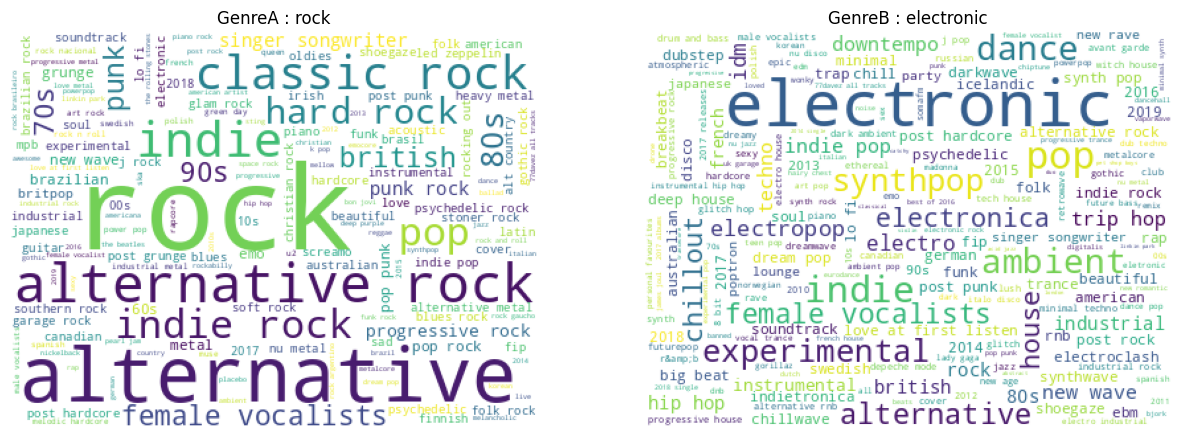

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

final_exploded = explode_df(df=final, to_explode="genres", new_name="genre")
genre_a, genre_b = top5_list[0], top5_list[2]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for a, genre,t in zip(axes, [genre_a, genre_b],['A','B']):
    genre_ids = final_exploded[final_exploded['genre'].isin([genre])]['id'].unique()
    tag_freq = Counter(
        t.strip()
        for tags in id_tags[id_tags['id'].isin(genre_ids)]['tags']
        for t in tags.split(',')
        if t.strip()
    )

    wc = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(tag_freq)
    a.imshow(wc)
    a.set_title(f'Genre{t} : {genre}')
    a.axis('off')

plt.show()

## Bar Chart

In [ ]:
chosen_id_genres_exploded = final.assign(gerne=chosen_id_genres['genres'].str.split(',')).explode('gerne')
chosen_id_genres_exploded['gerne'] = chosen_id_genres_exploded['gerne'].str.strip()

fig, axes = plt.subplots(len(top5_list), 1, figsize=(10, 5 * len(top5_list)))

for axis, genre in zip(axes, top5_list):
    genre_ids = chosen_id_genres_exploded[chosen_id_genres_exploded['gerne'] == genre]['id'].unique()
    tag_freq = Counter(
        t.strip()
        for tags in id_tags[id_tags['id'].isin(genre_ids)]['tags']
        for t in tags.split(',')
        if t.strip()
    )
    top10 = tag_freq.most_common(10)
    labels = [x[0] for x in top10]
    counts = [x[1] for x in top10]
    axis.barh(labels, counts)
    axis.invert_yaxis()
    axis.set_title(f'Top 10 Tags: {genre}')

plt.tight_layout()
plt.show()


/tmp/ipykernel_18133/1902026765.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  chosen_id_genres_exploded = final.assign(gerne=chosen_id_genres['genres'].str.split(',')).explode('gerne')


NameError: name 'plt' is not defined

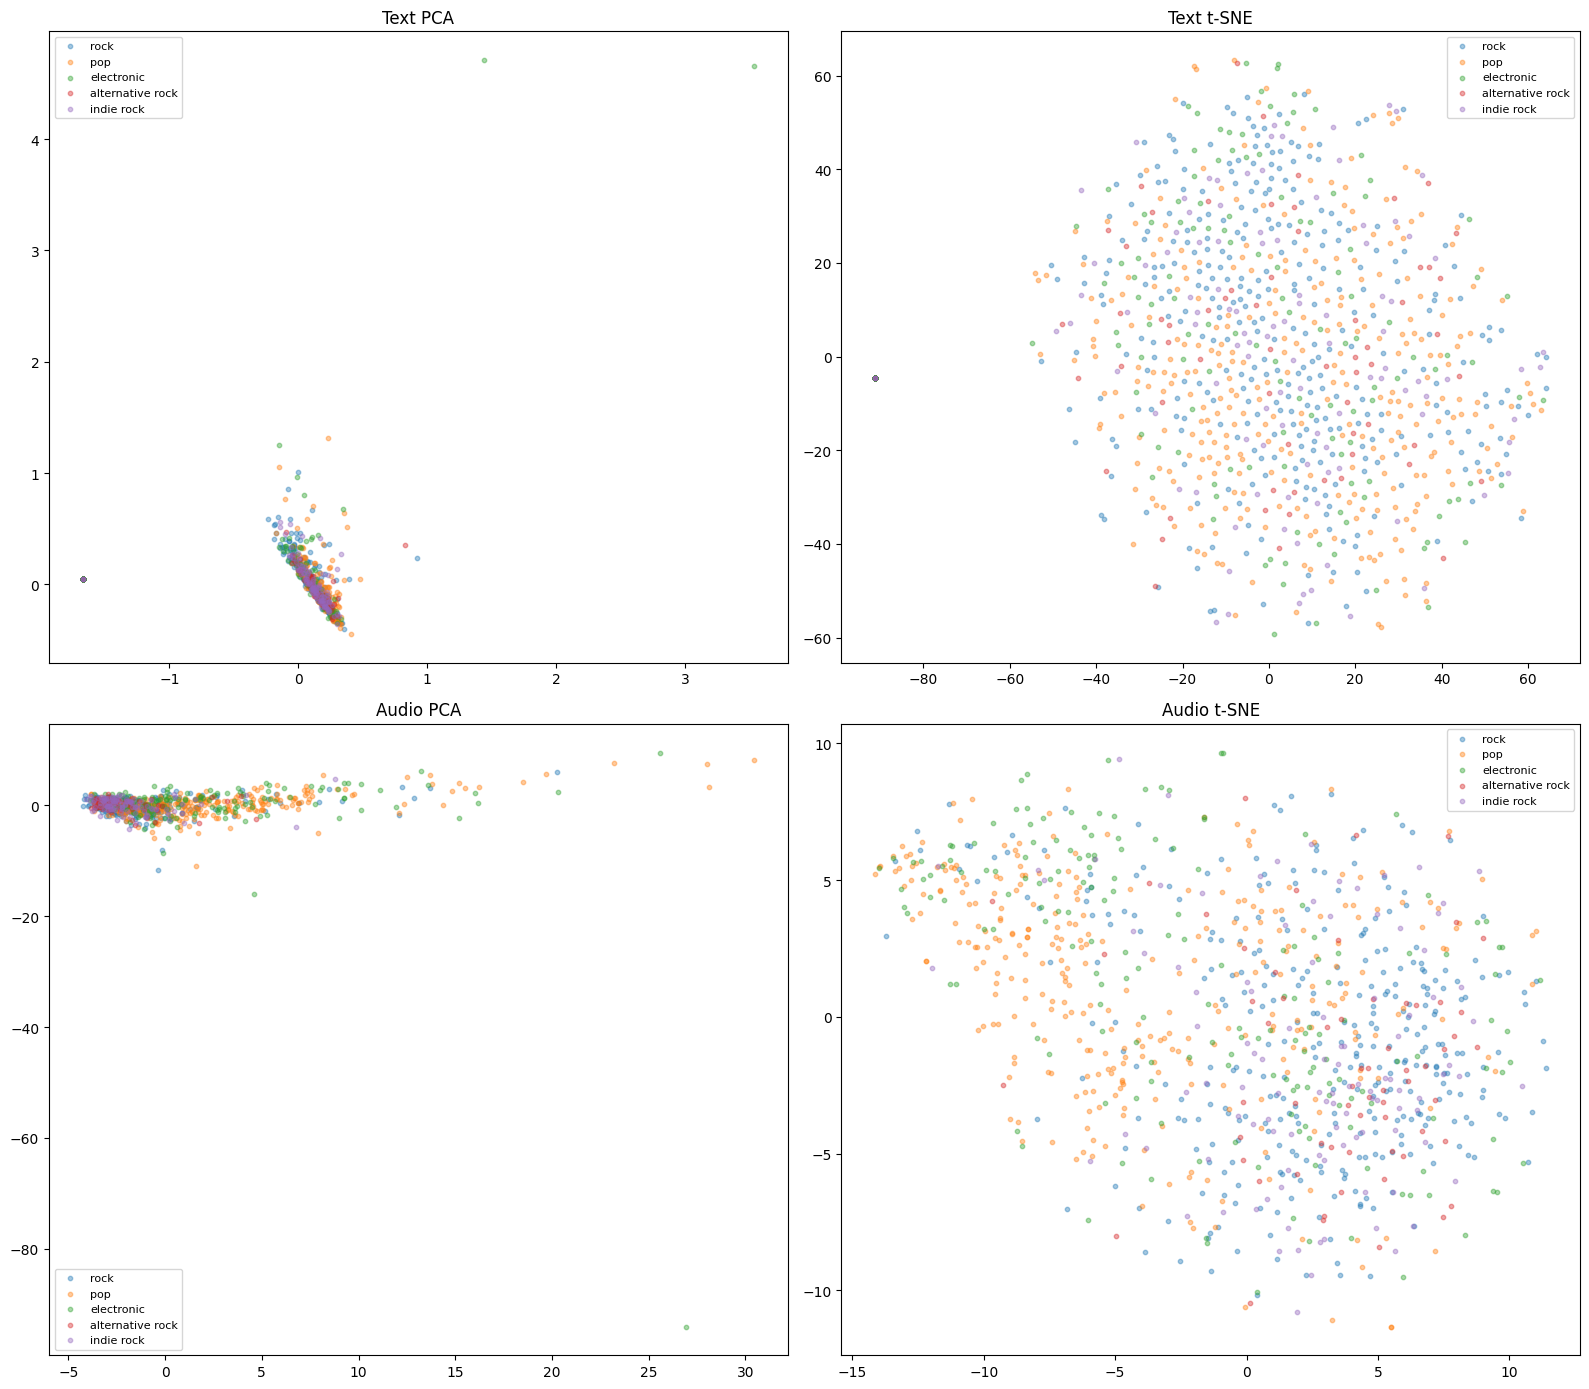

In [ ]:
from sklearn.manifold import TSNE

def first_top5(gernes, top5):
    for gerne in gernes.split(','):
        if gerne.strip() in top5:
            return gerne.strip()
    return None

final['primary_genre'] = finall['genres'].apply(lambda x: first_top5(x, top5_list))
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Text PCA 2D
text_2d_pca = PCA(n_components=2).fit_transform(text_embeddings)
# Text t-SNE
text_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(text_embeddings)
# Audio PCA 2D
audio_2d_pca = PCA(n_components=2).fit_transform(audio_embeddings)
# Audio t-SNE
audio_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_embeddings)

titles = ['Text PCA', 'Text t-SNE', 'Audio PCA', 'Audio t-SNE']
data = [text_2d_pca, text_2d_tsne, audio_2d_pca, audio_2d_tsne]

for ax, title, d in zip(axes.flat, titles, data):
    for genre in top5_list:
        mask = final['primary_genre'].values == genre
        ax.scatter(d[mask, 0], d[mask, 1], label=genre, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_18133/1238713266.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final['genre_count'] =final['genres'].str.split(',').apply(len)


0       4
1       3
2       3
3       1
4       3
       ..
7495    3
7496    1
7497    3
7498    3
7499    2
Name: genre_count, Length: 7500, dtype: int64

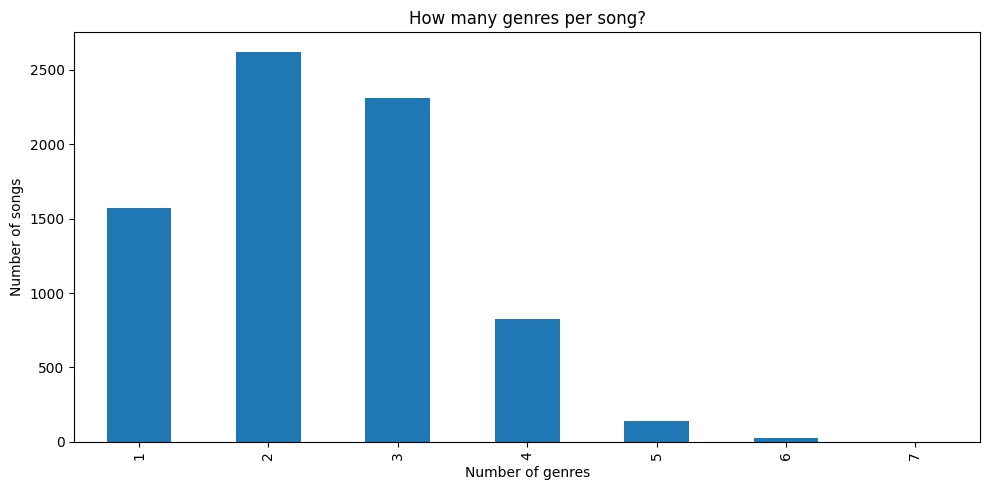

In [41]:
final['genre_count'] =final['genres'].str.split(',').apply(len)


display(final["genre_count"])

fig, ax = plt.subplots(figsize=(10, 5))
final['genre_count'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Number of genres')
ax.set_ylabel('Number of songs')
ax.set_title('How many genres per song?')
plt.tight_layout()
plt.show()


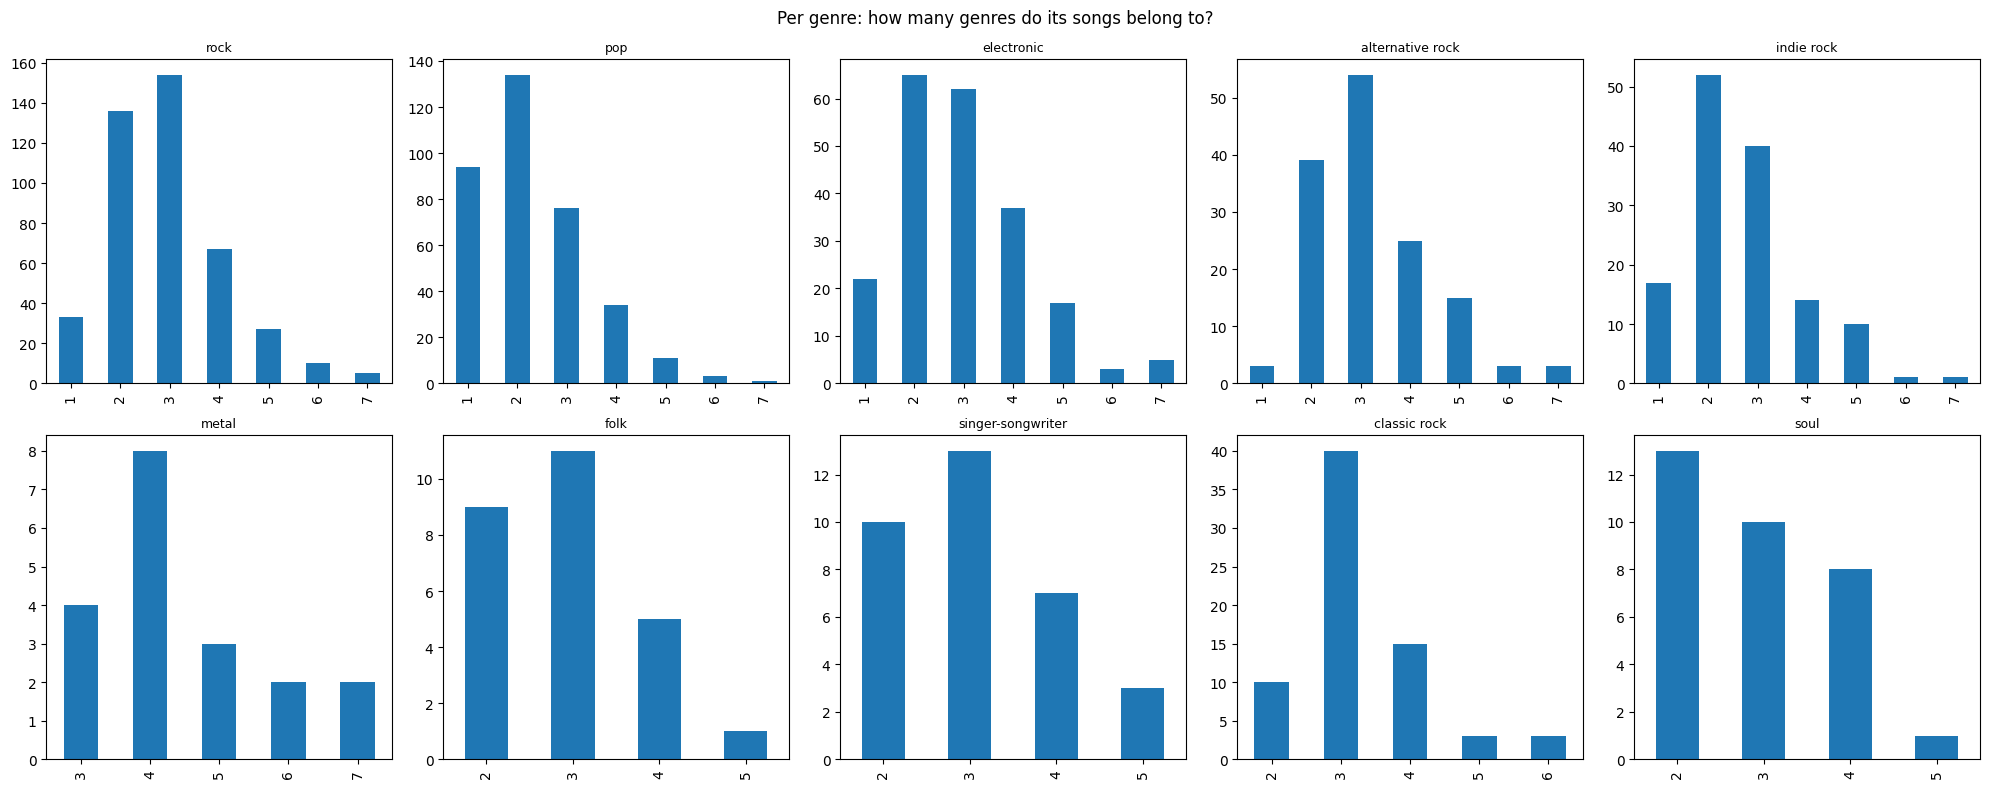

In [ ]:
top10_genres = genre_exploded['genre'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, genre in zip(axes.flat, top10_genres):
    genre_songs = genre_exploded[genre_exploded['genre'] == genre]['id']
    counts = final[finall['id'].isin(genre_songs)]['genres'].str.split(',').apply(len)
    if len(counts) > 0:
        counts.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(genre, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Per genre: how many genres do its songs belong to?')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1847/1207018742.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['word_count'] = full['lyrics'].str.split().apply(len)
/tmp/ipykernel_1847/1207018742.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['char_count'] = full['lyrics'].str.len()
/tmp/ipykernel_1847/1207018742.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a 

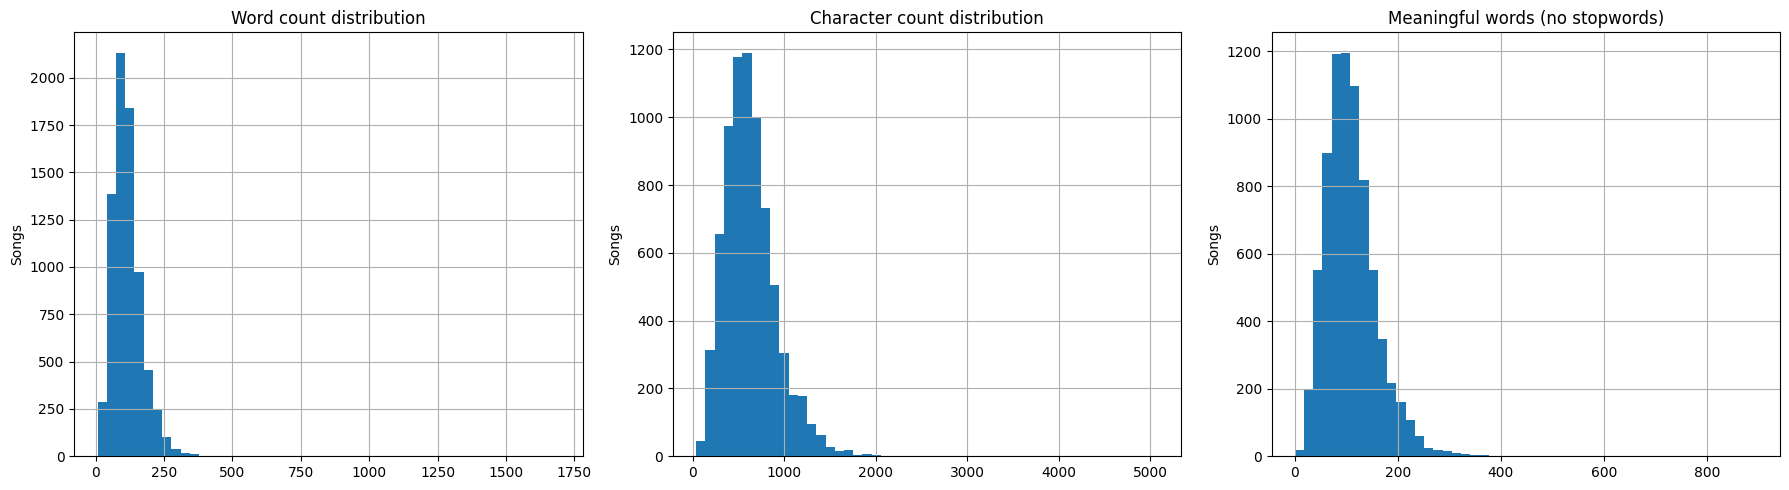

Avg words: 116, Avg meaningful: 110


In [ ]:
full['word_count'] = full['lyrics'].str.split().apply(len)
full['char_count'] = final['lyrics'].str.len()
full['meaningful_words'] = full['tokens'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

full['word_count'].hist(bins=50, ax=axes[0])
axes[0].set_title('Word count distribution')

full['char_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('Character count distribution')

full['meaningful_words'].hist(bins=50, ax=axes[2])
axes[2].set_title('Meaningful words (no stopwords)')

for ax in axes:
    ax.set_ylabel('Songs')

plt.tight_layout()
plt.show()

print(f"Avg words: {full['word_count'].mean():.0f}, Avg meaningful: {final['meaningful_words'].mean():.0f}")


In [152]:
from sklearn.metrics.pairwise import cosine_similarity

sample_idx = 0
sample = full.iloc[sample_idx]
print(f"Query: {sample['id']} | genre: {sample['genres']}\n")

# Text similarity
text_sim = cosine_similarity([text_embeddings[sample_idx]], text_embeddings)[0]
text_top5 = text_sim.argsort()[-6:-1][::-1]

print("Top 5 similar by LYRICS:")
for i in text_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {text_sim[i]:.4f}")

# Audio similarity
audio_sim = cosine_similarity([audio_embeddings[sample_idx]], audio_embeddings)[0]
audio_top5 = audio_sim.argsort()[-6:-1][::-1]

print("\nTop 5 similar by AUDIO:")
for i in audio_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {audio_sim[i]:.4f}")


Query: p57NIYlOER9ShCje | genre: rock,britpop,alternative rock

Top 5 similar by LYRICS:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 0.9714
  VAGbVYpDCZe8KuYm | nu metal,rock,alternative rock,metal,hard rock | sim: 0.8368
  1MMLKM3p1GQwmNj3 | electronic | sim: 0.8339
  QUJ8zKT2xvrShIlP | classic rock,rock,soft rock | sim: 0.8318
  4edtfURJHArBQ9NO | progressive rock,classic rock,rock | sim: 0.8295

Top 5 similar by AUDIO:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 1.0000
  HZs392QkmLezrFDR | rock | sim: 0.4081
  2ueJb7jjsNvxv9FA | rock,classic rock,pop,soft rock | sim: 0.4024
  fNHGdyMGoNWomVy5 | rock,indie rock | sim: 0.3983
  mE2cBRO5douAH96W | folk,singer-songwriter,rock,folk rock | sim: 0.3927
